In [1]:
import sapien
import sys
import json
import gymnasium as gym
import torch
from tqdm import tqdm
import argparse
import os
from pathlib import Path
import time 
import hydra
import matplotlib.pyplot as plt
import cv2
import os
os.chdir('..')

import mani_skill.envs
from mani_skill.utils.wrappers import RecordEpisode
from mani_skill.utils.structs.pose import Pose

import sys 
sys.path.append('..')
from dsynth.envs import *
from dsynth.robots import *
from dsynth.annotate_obs import prepare_observations, extract_reachable_products

/data/home/soshin/envs/dsynth/lib/python3.10/site-packages/sapien/__init__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/data/home/soshin/envs/dsynth/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
env = gym.make('RandomItemDeletionEnv', 
                   robot_uids='ds_fetch_basket', 
                   config_dir_path = '/data/home/soshin/repo/darkstore-synthesizer/generated_envs/cluttered',
                   num_envs=1, 
                   viewer_camera_configs={'shader_pack': 'default'}, 
                    human_render_camera_configs={'shader_pack': 'default'},
                    sensor_configs={'shader_pack': 'default'},
                   render_mode="rgb_array",
                #    render_mode="rgb_array", 
                   control_mode='pd_ee_delta_pose',
                   enable_shadow=True,
                   sim_config={'spacing': 20},
                   obs_mode='rgb+segmentation',
                   sim_backend='auto',
                   parallel_in_single_scene = False,
                   )

/data/home/soshin/envs/dsynth/lib/python3.10/site-packages/torch/random.py:187: UserWarning: CUDA reports that you have 2 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you are only making use of a few CUDA devices, set the environment variable CUDA_VISIBLE_DEVICES or the 'devices' keyword argument of fork_rng with the set of devices you are actually using. For example, if you are using CPU only, set device.upper()_VISIBLE_DEVICES= or devices=[]; if you are using device 0 only, set CUDA_VISIBLE_DEVICES=0 or devices=[0].  To initialize all devices and suppress this warning, set the 'devices' keyword argument to `range(torch.cuda.device_count())`.
  warnings.warn(message)
/data/home/soshin/repo/darkstore-synthesizer/dsynth/envs/darkstore_cont_base.py:193: UserWarning: Creating a tensor from a list of nump

built
Total 93 products in 1 scene(s)


In [9]:
obs = prepare_observations(env)

In [10]:
obs.keys()

dict_keys(['left_base_camera_link', 'fetch_hand', 'right_base_camera_link', 'combined', 'scene_description', 'bboxes'])

In [11]:
obs['left_base_camera_link'].keys()

dict_keys(['image', 'annotated_image'])

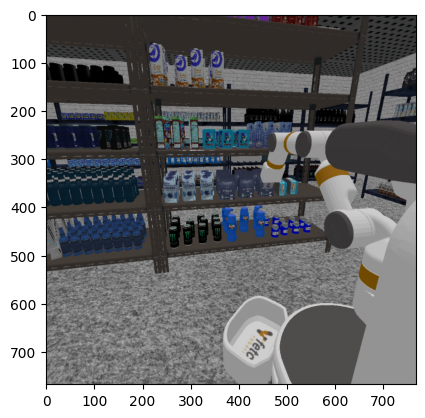

In [12]:
plt.imshow(obs['left_base_camera_link']['image'])

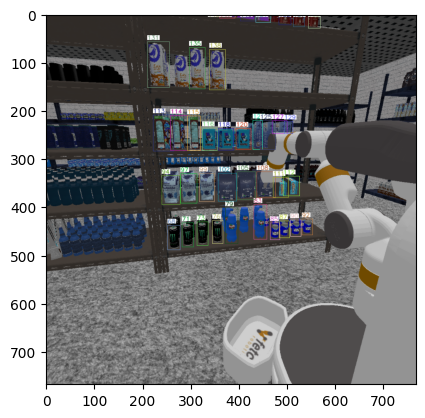

In [13]:
plt.imshow(obs['left_base_camera_link']['annotated_image'])

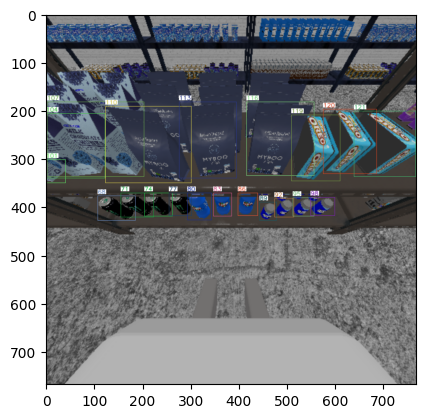

In [8]:
plt.imshow(obs['fetch_hand']['annotated_image'])

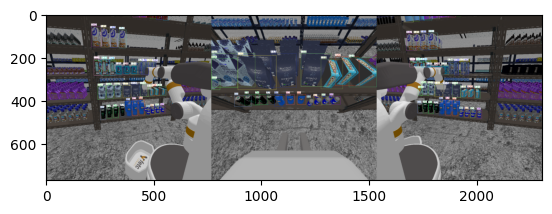

In [9]:
plt.imshow(obs['combined']['annotated_image'])

In [10]:
cv2.imwrite('output_image.jpg', obs['combined']['annotated_image'])

True

In [62]:
extract_reachable_products(env)

([68,
  71,
  74,
  77,
  80,
  83,
  86,
  88,
  91,
  94,
  97,
  100,
  103,
  106,
  108,
  110,
  113,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  124,
  127,
  129,
  131,
  133,
  135,
  136,
  139,
  142,
  147,
  149,
  151,
  153,
  155,
  157,
  159,
  160,
  164,
  169],
 ['[ENV#0]_food.ENERGY_DRINKS.MonsterEnergyDrink:0:0:0:0',
  '[ENV#0]_food.ENERGY_DRINKS.MonsterEnergyDrink:0:0:1:0',
  '[ENV#0]_food.ENERGY_DRINKS.MonsterEnergyDrink:0:0:2:0',
  '[ENV#0]_food.ENERGY_DRINKS.MonsterEnergyDrink:0:0:3:0',
  '[ENV#0]_food.DRINKS_SODA.FantaSaborNaranja2L:0:0:0:0',
  '[ENV#0]_food.DRINKS_SODA.FantaSaborNaranja2L:0:0:1:0',
  '[ENV#0]_food.DRINKS_SODA.FantaSaborNaranja2L:0:0:2:0',
  '[ENV#0]_food.BEER.DuffBeerCan:0:0:0:0',
  '[ENV#0]_food.BEER.DuffBeerCan:0:0:1:0',
  '[ENV#0]_food.BEER.DuffBeerCan:0:0:2:0',
  '[ENV#0]_food.BEER.DuffBeerCan:0:0:3:0',
  '[ENV#0]_food.CRACKERS_COOKIES.BarryCallebautMilkChockolateChunks:0:1:0:0',
  '[ENV#0]_food.CRACKERS_COOKIES.BarryCallebautMi

In [63]:
obs['scene_description']

{'robot': {'base_position': [5.682, 5.247, 0.0],
  'ee_position': [5.681, 4.375, 0.771],
  'joints': [{'name': 'torso_lift_joint', 'qpos': 0.0, 'limits': [0.0, 0.386]},
   {'name': 'head_pan_joint', 'qpos': 0.0, 'limits': [-1.57, 1.57]},
   {'name': 'shoulder_pan_joint', 'qpos': 0.0, 'limits': [-1.606, 1.606]},
   {'name': 'head_tilt_joint', 'qpos': 0.0, 'limits': [-0.76, 1.45]},
   {'name': 'shoulder_lift_joint', 'qpos': -0.785, 'limits': [-1.221, 1.518]},
   {'name': 'upperarm_roll_joint', 'qpos': 0.0, 'limits': [-3.141, 3.141]},
   {'name': 'elbow_flex_joint', 'qpos': 0.785, 'limits': [-2.251, 2.251]},
   {'name': 'forearm_roll_joint', 'qpos': 0.0, 'limits': [-3.141, 3.141]},
   {'name': 'wrist_flex_joint', 'qpos': 1.047, 'limits': [-2.16, 2.16]},
   {'name': 'wrist_roll_joint', 'qpos': 0.0, 'limits': [-3.141, 3.141]},
   {'name': 'r_gripper_finger_joint', 'qpos': 0.015, 'limits': [0.0, 0.05]},
   {'name': 'l_gripper_finger_joint', 'qpos': 0.015, 'limits': [0.0, 0.05]}]},
 'shelf': 

In [77]:
obs['bboxes'].keys()

dict_keys(['left_base_camera_link', 'fetch_hand', 'right_base_camera_link'])

In [12]:
shelf_width = 1.517
shelf_depth = 0.5172


In [13]:
shelf_name = env.unwrapped.active_shelves[0][0]
shelf_pose = env.unwrapped.actors["fixtures"]["shelves"][shelf_name].pose.sp
shelf_pose

Pose([5.68, 3.8472, 0], [0.000796327, 0, 0, 1])

In [14]:
direction_to_shelf = shelf_pose.to_transformation_matrix()[:3, 1]
direction_to_shelf

array([-0.00159265, -0.9999988 ,  0.        ], dtype=float32)

In [15]:
np.arccos(np.dot(direction_to_shelf, np.array([1, 0, 0])))

1.5723889803404076

In [16]:
x_len = shelf_width
y_len = shelf_depth
if np.abs(np.dot(direction_to_shelf, [0, 1, 0])) < 1e-2:
    x_len = shelf_depth
    y_len = shelf_width
shelf_center = shelf_pose.p.copy()
board_bbox = [shelf_center[0] - x_len / 2, 
              shelf_center[1] - y_len / 2,
              shelf_center[0] + x_len / 2, 
              shelf_center[1] + y_len / 2]
board_bbox

[4.921499828338623, 3.588600393676758, 6.438499828338623, 4.105800393676758]

In [17]:
from mani_skill.examples.motionplanning.base_motionplanner.utils import get_actor_obb
def get_bbox(actor):
    obb = get_actor_obb(actor)
    extents = np.array(obb.extents)
    T = np.array(obb.transform)
    center = T[:3, 3]

    for i in range(3):
        if np.abs(T[:3, i] @ [0, 0, 1]) > 1e-1:
            height_extent_ids = i
            break

    inds = np.array([0, 1, 2])
    inds = inds[inds != height_extent_ids]

    h, w = extents[inds]

    return [
        center[0] - h / 2,
        center[1] - w / 2,
        center[0] + h / 2,
        center[1] + w / 2,
    ]
    

In [18]:
# get_bbox(env.unwrapped.actors["fixtures"]["shelves"][shelf_name])

In [21]:
# items_id = ['[ENV#0]_food.dairy_products.milkCarton:0:2:0:0',
#   '[ENV#0]_food.dairy_products.milkCarton:0:2:1:0',
#   '[ENV#0]_food.dairy_products.milkCarton:0:2:2:0',
#   '[ENV#0]_food.dairy_products.milkCarton:0:2:3:0',
#   '[ENV#0]_food.dairy_products.milkCarton:0:2:4:0',
#   '[ENV#0]_food.dairy_products.milkCarton:0:2:5:0',
#   '[ENV#0]_food.dairy_products.milkCarton:0:2:6:0',
#   '[ENV#0]_food.dairy_products.milkCarton:0:2:7:0']
items_id = ['[ENV#0]_food.HOUSEHOLD.AceDetergent:0:4:0:0',
'[ENV#0]_food.HOUSEHOLD.AceDetergent:0:4:0:1',
'[ENV#0]_food.HOUSEHOLD.AceDetergent:0:4:1:0',
'[ENV#0]_food.HOUSEHOLD.AceDetergent:0:4:1:1',
'[ENV#0]_food.HOUSEHOLD.AceDetergent:0:4:2:0',
'[ENV#0]_food.HOUSEHOLD.AceDetergent:0:4:2:1',
'[ENV#0]_food.HOUSEHOLD.VanishStainRemover:0:4:0:0',
'[ENV#0]_food.HOUSEHOLD.VanishStainRemover:0:4:0:1',
'[ENV#0]_food.HOUSEHOLD.VanishStainRemover:0:4:1:0',
'[ENV#0]_food.HOUSEHOLD.VanishStainRemover:0:4:1:1',
'[ENV#0]_food.HOUSEHOLD.VanishStainRemover:0:4:2:0',
'[ENV#0]_food.HOUSEHOLD.VanishStainRemover:0:4:2:1',
'[ENV#0]_food.HOUSEHOLD.VanishStainRemover:0:4:3:0',
'[ENV#0]_food.HOUSEHOLD.VanishStainRemover:0:4:3:1',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:0:0',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:0:1',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:0:2',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:0:3',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:0:4',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:1:0',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:1:1',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:1:2',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:1:3',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:1:4',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:2:0',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:2:1',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:2:2',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:2:3',
'[ENV#0]_food.HYGIENE.NiveaBodyMilk:0:4:2:4',

           ]
item_bboxes = []
border_items = extract_reachable_products(env)[1]
for item_id in items_id:
    # if item_id in border_items:
    actor = env.unwrapped.actors['products'][item_id]
    item_bboxes.append(get_bbox(actor))

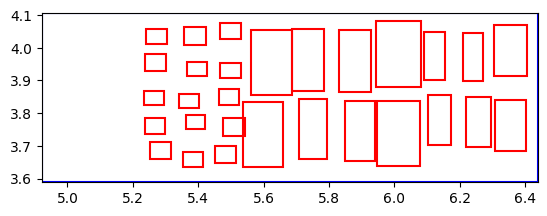

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
# bboxes = [[0, 0, 2, 1], [3, 1, 5, 4]]  # [[x_min, y_min, x_max, y_max], ...]
fig, ax = plt.subplots()
ax.set_aspect("equal")
for xmin, ymin, xmax, ymax in [board_bbox]:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="blue", linewidth=1.5)
    ax.add_patch(rect)
    
for xmin, ymin, xmax, ymax in item_bboxes:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="red", linewidth=1.5)
    ax.add_patch(rect)
all_bboxes = [board_bbox] + item_bboxes
# Optional: include all boxes in view
if all_bboxes:
    xs = [c for b in all_bboxes for c in (b[0], b[2])]
    ys = [c for b in all_bboxes for c in (b[1], b[3])]
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
plt.show()

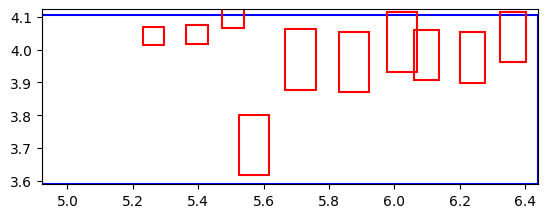

In [79]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
# bboxes = [[0, 0, 2, 1], [3, 1, 5, 4]]  # [[x_min, y_min, x_max, y_max], ...]
fig, ax = plt.subplots()
ax.set_aspect("equal")
for xmin, ymin, xmax, ymax in [board_bbox]:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="blue", linewidth=1.5)
    ax.add_patch(rect)
    
for xmin, ymin, xmax, ymax in item_bboxes:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="red", linewidth=1.5)
    ax.add_patch(rect)
all_bboxes = [board_bbox] + item_bboxes
# Optional: include all boxes in view
if all_bboxes:
    xs = [c for b in all_bboxes for c in (b[0], b[2])]
    ys = [c for b in all_bboxes for c in (b[1], b[3])]
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
plt.show()

In [23]:
from typing import List, Tuple

Rect = Tuple[float, float, float, float]  # (x1, y1, x2, y2)

def area(r: Rect) -> float:
    return max(0.0, r[2]-r[0]) * max(0.0, r[3]-r[1])

def intersect(a: Rect, b: Rect):
    x1 = max(a[0], b[0]); y1 = max(a[1], b[1])
    x2 = min(a[2], b[2]); y2 = min(a[3], b[3])
    if x1 < x2 and y1 < y2:
        return (x1, y1, x2, y2)
    return None

def subtract_rect(free_r: Rect, occ: Rect) -> List[Rect]:
    """Subtract occ from free_r, return up to 4 rectangles."""
    inter = intersect(free_r, occ)
    if not inter:
        return [free_r]

    fx1, fy1, fx2, fy2 = free_r
    ix1, iy1, ix2, iy2 = inter
    out = []

    # Left strip
    if fx1 < ix1:
        out.append((fx1, fy1, ix1, fy2))
    # Right strip
    if ix2 < fx2:
        out.append((ix2, fy1, fx2, fy2))
    # Bottom strip
    if fy1 < iy1:
        out.append((ix1, fy1, ix2, iy1))
    # Top strip
    if iy2 < fy2:
        out.append((ix1, iy2, ix2, fy2))

    return [r for r in out if area(r) > 0]

def contained(a: Rect, b: Rect) -> bool:
    return a[0] >= b[0] and a[1] >= b[1] and a[2] <= b[2] and a[3] <= b[3]

def prune_contained(rects: List[Rect]) -> List[Rect]:
    pruned = []
    for i, r in enumerate(rects):
        if not any(i != j and contained(r, rects[j]) for j in range(len(rects))):
            pruned.append(r)
    return pruned

def free_rectangles(shelf: Rect, items: List[Rect]) -> List[Rect]:
    free = [shelf]
    for occ in items:
        new_free = []
        for fr in free:
            new_free.extend(subtract_rect(fr, occ))
        free = prune_contained(new_free)
    return free

def find_place_for_new_box(free: List[Rect], w: float, h: float):
    # candidates where new box fits
    candidates = [r for r in free if (r[2]-r[0]) >= w and (r[3]-r[1]) >= h]
    if not candidates:
        return None

    # choose "best fit": minimal leftover area
    best = min(candidates, key=lambda r: (r[2]-r[0])*(r[3]-r[1]) - w*h)
    x1, y1, _, _ = best
    return (x1, y1, x1 + w, y1 + h)

def largest_free_zone_bbox(free: List[Rect]):
    return max(free, key=area) if free else None

In [34]:
free = free_rectangles(board_bbox, item_bboxes)
# free

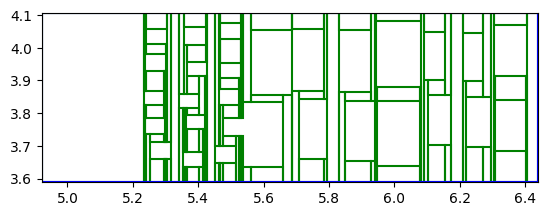

In [38]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
# bboxes = [[0, 0, 2, 1], [3, 1, 5, 4]]  # [[x_min, y_min, x_max, y_max], ...]
fig, ax = plt.subplots()
ax.set_aspect("equal")

for xmin, ymin, xmax, ymax in free:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="green", linewidth=1.5)
    ax.add_patch(rect)

for xmin, ymin, xmax, ymax in [board_bbox]:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="blue", linewidth=1.5)
    ax.add_patch(rect)
    
# for xmin, ymin, xmax, ymax in item_bboxes:
#     w, h = xmax - xmin, ymax - ymin
#     rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="red", linewidth=1.5)
#     ax.add_patch(rect)
# all_bboxes = [board_bbox] + item_bboxes

# Optional: include all boxes in view
if all_bboxes:
    xs = [c for b in all_bboxes for c in (b[0], b[2])]
    ys = [c for b in all_bboxes for c in (b[1], b[3])]
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
plt.show()

In [27]:
def find_place_for_new_box(free: List[Rect], w: float, h: float):
    # candidates where new box fits
    candidates = [r for r in free if (r[2]-r[0]) >= w and (r[3]-r[1]) >= h]
    if not candidates:
        return None
    # choose "best fit": minimal leftover area
    # best = min(candidates, key=lambda r: (r[2]-r[0])*(r[3]-r[1]) - w*h)
    # x1, y1, _, _ = best
    # return (x1, y1, x1 + w, y1 + h)
    return candidates

In [32]:
free_spaces = find_place_for_new_box(free, w = 0.05, h=0.05)

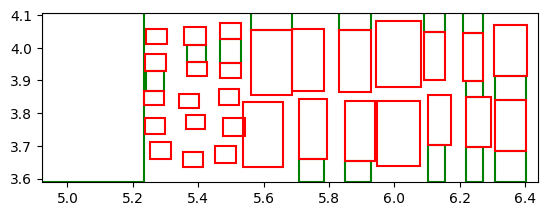

In [37]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
# bboxes = [[0, 0, 2, 1], [3, 1, 5, 4]]  # [[x_min, y_min, x_max, y_max], ...]
fig, ax = plt.subplots()
ax.set_aspect("equal")

for xmin, ymin, xmax, ymax in free_spaces:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="green", linewidth=1.5)
    ax.add_patch(rect)

# for xmin, ymin, xmax, ymax in [board_bbox]:
#     w, h = xmax - xmin, ymax - ymin
#     rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="blue", linewidth=1.5)
#     ax.add_patch(rect)
    
for xmin, ymin, xmax, ymax in item_bboxes:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="red", linewidth=1.5)
    ax.add_patch(rect)
all_bboxes = [board_bbox] + item_bboxes

# Optional: include all boxes in view
if all_bboxes:
    xs = [c for b in all_bboxes for c in (b[0], b[2])]
    ys = [c for b in all_bboxes for c in (b[1], b[3])]
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
plt.show()

In [40]:
from typing import List, Tuple, Optional

Rect = Tuple[float, float, float, float]

def intersect(a: Rect, b: Rect) -> Optional[Rect]:
    x1, y1 = max(a[0], b[0]), max(a[1], b[1])
    x2, y2 = min(a[2], b[2]), min(a[3], b[3])
    return (x1, y1, x2, y2) if x1 < x2 and y1 < y2 else None

def subtract_rect(free_r: Rect, block: Rect) -> List[Rect]:
    inter = intersect(free_r, block)
    if not inter:
        return [free_r]
    fx1, fy1, fx2, fy2 = free_r
    ix1, iy1, ix2, iy2 = inter
    out = []
    if fx1 < ix1: out.append((fx1, fy1, ix1, fy2))  # left
    if ix2 < fx2: out.append((ix2, fy1, fx2, fy2))  # right
    if fy1 < iy1: out.append((ix1, fy1, ix2, iy1))  # bottom
    if iy2 < fy2: out.append((ix1, iy2, ix2, fy2))  # top
    return out

def feasible_anchor_regions(shelf: Rect, items: List[Rect], w: float, h: float) -> List[Rect]:
    sx1, sy1, sx2, sy2 = shelf
    domain = (sx1, sy1, sx2 - w, sy2 - h)
    if domain[0] >= domain[2] or domain[1] >= domain[3]:
        return []  # new box bigger than shelf

    free = [domain]
    for ox1, oy1, ox2, oy2 in items:
        forbidden = (ox1 - w, oy1 - h, ox2, oy2)
        forbidden = intersect(forbidden, domain)
        if not forbidden:
            continue
        nxt = []
        for fr in free:
            nxt.extend(subtract_rect(fr, forbidden))
        free = nxt
        if not free:
            break
    return free

def place_one(shelf: Rect, items: List[Rect], w: float, h: float) -> Optional[Rect]:
    regions = feasible_anchor_regions(shelf, items, w, h)
    if not regions:
        return None
    x, y = regions[0][0], regions[0][1]  # pick any valid anchor
    return (x, y, x + w, y + h)

In [41]:
res = feasible_anchor_regions(board_bbox, item_bboxes, w = 0.05, h=0.05)

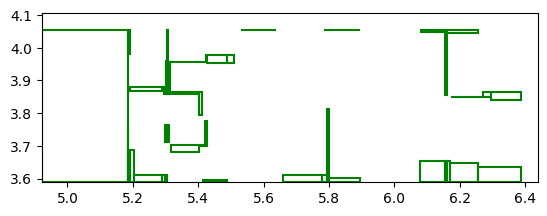

In [44]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
# bboxes = [[0, 0, 2, 1], [3, 1, 5, 4]]  # [[x_min, y_min, x_max, y_max], ...]
fig, ax = plt.subplots()
ax.set_aspect("equal")

for xmin, ymin, xmax, ymax in res:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="green", linewidth=1.5)
    ax.add_patch(rect)

# for xmin, ymin, xmax, ymax in [board_bbox]:
#     w, h = xmax - xmin, ymax - ymin
#     rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="blue", linewidth=1.5)
#     ax.add_patch(rect)
    
for xmin, ymin, xmax, ymax in item_bboxes:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="red", linewidth=1.5)
    ax.add_patch(rect)
all_bboxes = [board_bbox] + item_bboxes

# Optional: include all boxes in view
if all_bboxes:
    xs = [c for b in all_bboxes for c in (b[0], b[2])]
    ys = [c for b in all_bboxes for c in (b[1], b[3])]
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
plt.show()

In [45]:
import numpy as np
from typing import List, Tuple

BBox = Tuple[float, float, float, float]  # (x_min, y_min, x_max, y_max)

def build_occupancy_map(
    shelf_bbox: BBox,
    item_bboxes: List[BBox],
    resolution: float = 0.01,
) -> Tuple[np.ndarray, Tuple[float, float, float], Tuple[float, float]]:
    """
    Build occupancy map for one shelf.

    Args:
        shelf_bbox: (sx1, sy1, sx2, sy2) in world coords.
        item_bboxes: list of (x1, y1, x2, y2) in same coords.
        resolution: cell size in world units (e.g. meters/cell).

    Returns:
        occ: np.ndarray[H, W], uint8
             0 = free, 1 = occupied
        grid_meta: (x0, y0, resolution), where (x0,y0)=shelf min corner.
        map_size_world: (shelf_width, shelf_height)
    """
    sx1, sy1, sx2, sy2 = shelf_bbox
    if not (sx2 > sx1 and sy2 > sy1):
        raise ValueError("Invalid shelf bbox")
    if resolution <= 0:
        raise ValueError("resolution must be > 0")

    shelf_w = sx2 - sx1
    shelf_h = sy2 - sy1

    # Grid size (cover full shelf)
    W = int(np.ceil(shelf_w / resolution))
    H = int(np.ceil(shelf_h / resolution))

    occ = np.zeros((H, W), dtype=np.uint8)

    def world_to_grid_floor(x: float, y: float) -> Tuple[int, int]:
        gx = int(np.floor((x - sx1) / resolution))
        gy = int(np.floor((y - sy1) / resolution))
        return gx, gy

    def world_to_grid_ceil(x: float, y: float) -> Tuple[int, int]:
        gx = int(np.ceil((x - sx1) / resolution))
        gy = int(np.ceil((y - sy1) / resolution))
        return gx, gy

    for (x1, y1, x2, y2) in item_bboxes:
        # Ignore invalid boxes
        if not (x2 > x1 and y2 > y1):
            continue

        # Clip item to shelf (only overlap part matters)
        ix1 = max(x1, sx1)
        iy1 = max(y1, sy1)
        ix2 = min(x2, sx2)
        iy2 = min(y2, sy2)

        if not (ix2 > ix1 and iy2 > iy1):
            continue

        # Conservative rasterization:
        # floor for start, ceil for end -> mark any touched cell occupied
        gx1, gy1 = world_to_grid_floor(ix1, iy1)
        gx2, gy2 = world_to_grid_ceil(ix2, iy2)

        # Clamp to array bounds
        gx1 = max(0, min(W, gx1))
        gy1 = max(0, min(H, gy1))
        gx2 = max(0, min(W, gx2))
        gy2 = max(0, min(H, gy2))

        if gx2 > gx1 and gy2 > gy1:
            occ[gy1:gy2, gx1:gx2] = 1

    return occ, (sx1, sy1, resolution), (shelf_w, shelf_h)

In [137]:
occ_map, meta, shelf_sizes = build_occupancy_map(board_bbox, item_bboxes)
meta

(4.921499828338623, 3.588600393676758, 0.01)

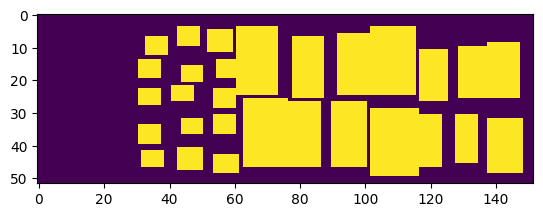

In [138]:
plt.imshow(occ_map)

In [139]:
np.unique(occ_map)

array([0, 1], dtype=uint8)

In [140]:
import cv2
def erode_occupancy_map(
    occ: np.ndarray,
    rect_size: Tuple[int, int],  # (width_cells, height_cells)
) -> np.ndarray:
    """
    Erode occupancy map with rectangular kernel using OpenCV.
    Input convention:
      - occ: 2D array, 0=free, 1=occupied
    Output:
      - eroded_occ: same convention (0=free, 1=occupied)
    Notes:
      - To find where a rectangle can fit, it's usually better to erode the FREE mask.
        This function keeps your occupancy convention and does:
          free = (occ == 0)
          free_eroded = erode(free, kernel)
          eroded_occ = 1 - free_eroded
    """
    if occ.ndim != 2:
        raise ValueError("occ must be a 2D array")
    kw, kh = rect_size
    if kw <= 0 or kh <= 0:
        raise ValueError("rect_size must be positive")
    # Convert to uint8 binary free-mask: 255=free, 0=occupied
    free_u8 = (occ == 0).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kw, kh))
    free_eroded = cv2.erode(free_u8, kernel, iterations=1)
    # Back to occupancy convention: 1=occupied, 0=free
    eroded_occ = (free_eroded == 0).astype(np.uint8)
    return eroded_occ


In [194]:
target_h, target_w = 0.1 / 2, 0.1 / 2
resolution = 0.01
occ_eroded = erode_occupancy_map(occ_map, rect_size=(int(target_h / resolution), int(target_w / resolution)))
np.unique(occ_eroded)

array([0, 1], dtype=uint8)

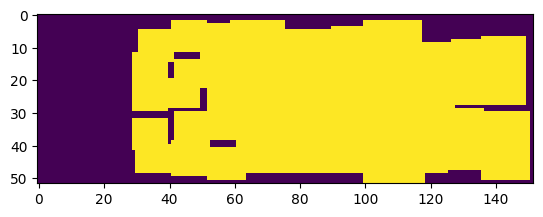

In [195]:
plt.imshow(occ_eroded)

In [196]:
free_map = 1 - occ_eroded

In [197]:
np.unique(free_map)

array([0, 1], dtype=uint8)

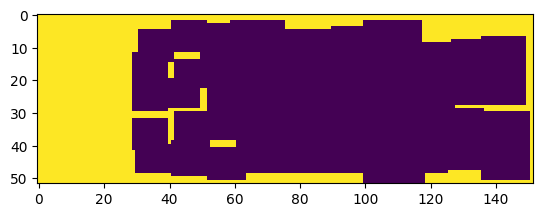

In [198]:
plt.imshow(free_map)

In [148]:
def connected_components_from_mask(mask: np.ndarray, connectivity: int = 8) -> List[Dict[str, Any]]:
    """
    Find connected components in a binary mask.
    Args:
        mask: 2D binary-like array. Non-zero pixels are treated as foreground.
        connectivity: 4 or 8
    Returns:
        List of components (excluding background), each dict has:
          - label: component id (>=1)
          - area: number of pixels
          - bbox_xyxy: (x_min, y_min, x_max, y_max)  # x_max/y_max are exclusive
          - centroid_xy: (cx, cy)
          - pixel_indices_yx: np.ndarray of shape [N, 2] with (y, x) pixels
    """
    if mask.ndim != 2:
        raise ValueError("mask must be 2D")
    if connectivity not in (4, 8):
        raise ValueError("connectivity must be 4 or 8")
    fg = (mask > 0).astype(np.uint8)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
        fg, connectivity=connectivity
    )
    comps = []
    for lbl in range(1, num_labels):  # skip background 0
        x = int(stats[lbl, cv2.CC_STAT_LEFT])
        y = int(stats[lbl, cv2.CC_STAT_TOP])
        w = int(stats[lbl, cv2.CC_STAT_WIDTH])
        h = int(stats[lbl, cv2.CC_STAT_HEIGHT])
        area = int(stats[lbl, cv2.CC_STAT_AREA])
        cx, cy = centroids[lbl]
        ys, xs = np.where(labels == lbl)
        pixel_indices_yx = np.stack([ys, xs], axis=1)
        comps.append({
            "label": lbl,
            "area": area,
            "bbox_xyxy": (x, y, x + w, y + h),  # exclusive max
            "centroid_xy": (float(cx), float(cy)),
            "pixel_indices_yx": pixel_indices_yx,
        })
    return comps


In [149]:
# occ_eroded_padded = np.zeros((occ_eroded.shape[0] + 2, occ_eroded.shape[1] + 2)) * 255
# occ_eroded_padded[1:-1, 1:-1] = ~occ_eroded * 255
comp = connected_components_from_mask(free_map)

In [157]:
free_map[comp[0]['pixel_indices_yx']].shape

(1461, 2, 152)

In [158]:
comp[0]['pixel_indices_yx']

array([[ 0,  0],
       [ 0,  1],
       [ 0,  2],
       ...,
       [51, 25],
       [51, 26],
       [51, 27]])

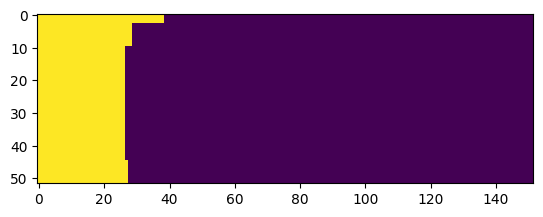

In [173]:
cur_comp = np.zeros_like(free_map)
idxs = comp[0]['pixel_indices_yx']
cur_comp[idxs[:, 0], idxs[:, 1]] = 1
plt.imshow(cur_comp)

In [174]:
def largest_rectangle_in_binary_matrix(mask: np.ndarray, target_value: int = 1) -> Tuple[int, int, int, int, int]:
    """
    Find the largest axis-aligned rectangle consisting only of target_value.
    Args:
        mask: 2D array-like (binary/int/bool).
        target_value: value treated as "fillable" (default=1).
    Returns:
        (x_min, y_min, x_max, y_max, area)
        where x_max/y_max are exclusive bounds.
        If none found -> (0, 0, 0, 0, 0)
    """
    if mask.ndim != 2:
        raise ValueError("mask must be 2D")
    # Normalize to 0/1 where 1 means usable cell
    m = (mask == target_value).astype(np.uint8)
    H, W = m.shape
    heights = np.zeros(W, dtype=np.int32)
    best_area = 0
    best = (0, 0, 0, 0)  # x1, y1, x2, y2
    for y in range(H):
        # Build histogram of consecutive 1s ending at row y
        heights = np.where(m[y] == 1, heights + 1, 0)
        # Largest rectangle in histogram (monotonic stack of (start_idx, height))
        stack = []
        for i in range(W + 1):
            cur_h = heights[i] if i < W else 0  # sentinel
            start = i
            while stack and stack[-1][1] > cur_h:
                idx, h = stack.pop()
                area = h * (i - idx)
                if area > best_area:
                    best_area = area
                    x1 = idx
                    x2 = i
                    y2 = y + 1
                    y1 = y2 - h
                    best = (x1, y1, x2, y2)
                start = idx
            if not stack or stack[-1][1] < cur_h:
                stack.append((start, cur_h))
    x1, y1, x2, y2 = best
    return x1, y1, x2, y2, best_area

In [179]:
largest_rect = largest_rectangle_in_binary_matrix(cur_comp)
largest_rect

(0, 0, 27, 52, 1404)

In [178]:
def point_idx_to_xy(point, start_point, descr=0.01):
    return np.array(point) * descr + start_point
def rect_idxs_to_xy(rects, start_point, descr=0.01):
    res = []
    for rect in rects:
        xy_min = point_idx_to_xy(rect[:2], start_point=start_point, descr=descr)
        xy_max = point_idx_to_xy(rect[2:], start_point=start_point, descr=descr)
        res.append([xy_min[0], xy_min[1], xy_max[0], xy_max[1]])
    return np.array(res)

In [181]:
rect_idxs_to_xy([largest_rect[:-1]], start_point=meta[:2])

array([[4.92149983, 3.58860039, 5.19149983, 4.10860039]])

In [190]:
free_spaces = []

for cur_comp in comp:
    cur_map = np.zeros_like(free_map)
    idxs = cur_comp['pixel_indices_yx']
    cur_map[idxs[:, 0], idxs[:, 1]] = 1

    largest_rect = largest_rectangle_in_binary_matrix(cur_map)
    free_space = rect_idxs_to_xy([largest_rect[:-1]], start_point=meta[:2])[0]
    free_space[0] -= target_h / 2
    free_space[1] -= target_w / 2
    free_space[0] += target_h / 2
    free_space[1] += target_w / 2
    free_spaces.append(rect_idxs_to_xy([largest_rect[:-1]], start_point=meta[:2])[0])
    

In [191]:
free_spaces

[array([4.92149983, 3.58860039, 5.19149983, 4.10860039]),
 array([5.47149983, 3.58860039, 5.49149983, 3.59860039]),
 array([5.71149983, 3.58860039, 5.90149983, 3.60860039]),
 array([6.13149983, 3.58860039, 6.44149983, 3.63860039]),
 array([6.21149983, 4.09860039, 6.26149983, 4.10860039])]

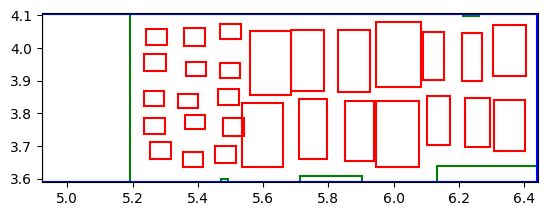

In [192]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
# bboxes = [[0, 0, 2, 1], [3, 1, 5, 4]]  # [[x_min, y_min, x_max, y_max], ...]
fig, ax = plt.subplots()
ax.set_aspect("equal")

for xmin, ymin, xmax, ymax in free_spaces:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="green", linewidth=1.5)
    ax.add_patch(rect)

for xmin, ymin, xmax, ymax in [board_bbox]:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="blue", linewidth=1.5)
    ax.add_patch(rect)
    
for xmin, ymin, xmax, ymax in item_bboxes:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="red", linewidth=1.5)
    ax.add_patch(rect)
all_bboxes = [board_bbox] + item_bboxes + free_spaces

# Optional: include all boxes in view
if all_bboxes:
    xs = [c for b in all_bboxes for c in (b[0], b[2])]
    ys = [c for b in all_bboxes for c in (b[1], b[3])]
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
plt.show()

# RandomItemDeletionEnv

In [1]:
import sapien
import sys
import json
import gymnasium as gym
import torch
from tqdm import tqdm
import argparse
import os
from pathlib import Path
import time 
import hydra
import matplotlib.pyplot as plt
import cv2
import os
os.chdir('..')

import mani_skill.envs
from mani_skill.utils.wrappers import RecordEpisode
from mani_skill.utils.structs.pose import Pose

import sys 
sys.path.append('..')
from dsynth.envs import *
from dsynth.robots import *
from dsynth.annotate_obs import prepare_observations, extract_reachable_products
from dsynth.auxiliary.empty_space_detection import build_free_spaces

/data/home/soshin/envs/dsynth/lib/python3.10/site-packages/sapien/__init__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/data/home/soshin/envs/dsynth/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
env = gym.make('RandomItemDeletionEnv', 
                   robot_uids='ds_fetch_basket', 
                   config_dir_path = '/data/home/soshin/repo/darkstore-synthesizer/generated_envs/cluttered',
                   num_envs=1, 
                   viewer_camera_configs={'shader_pack': 'default'}, 
                    human_render_camera_configs={'shader_pack': 'default'},
                    sensor_configs={'shader_pack': 'default'},
                   render_mode="rgb_array",
                #    render_mode="rgb_array", 
                   control_mode='pd_ee_delta_pose',
                   enable_shadow=True,
                   sim_config={'spacing': 20},
                   obs_mode='rgb+segmentation',
                   sim_backend='auto',
                   parallel_in_single_scene = False,
                   )

/data/home/soshin/envs/dsynth/lib/python3.10/site-packages/torch/random.py:187: UserWarning: CUDA reports that you have 2 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you are only making use of a few CUDA devices, set the environment variable CUDA_VISIBLE_DEVICES or the 'devices' keyword argument of fork_rng with the set of devices you are actually using. For example, if you are using CPU only, set device.upper()_VISIBLE_DEVICES= or devices=[]; if you are using device 0 only, set CUDA_VISIBLE_DEVICES=0 or devices=[0].  To initialize all devices and suppress this warning, set the 'devices' keyword argument to `range(torch.cuda.device_count())`.
  warnings.warn(message)
/data/home/soshin/repo/darkstore-synthesizer/dsynth/envs/darkstore_cont_base.py:193: UserWarning: Creating a tensor from a list of nump

built
Total 93 products in 1 scene(s)


In [3]:
_ = env.unwrapped.reset(420, options={'reconfigure': True})

built
Total 89 products in 1 scene(s)


In [4]:
# env.unwrapped.actors['free_spaces']

In [5]:
# env.unwrapped._hidden_objects.append(env.unwrapped.actors['free_spaces']['[ENV#0]_free_space_2_0'])

In [6]:
obs = prepare_observations(env)

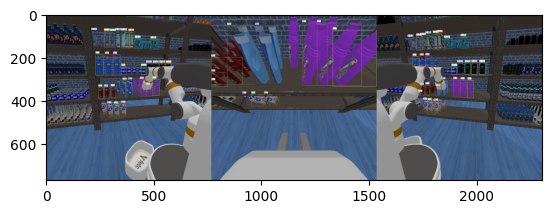

In [10]:
plt.imshow(obs['combined']['annotated_image'])

In [9]:
build_free_spaces(env.unwrapped)

In [10]:
obs = prepare_observations(env)

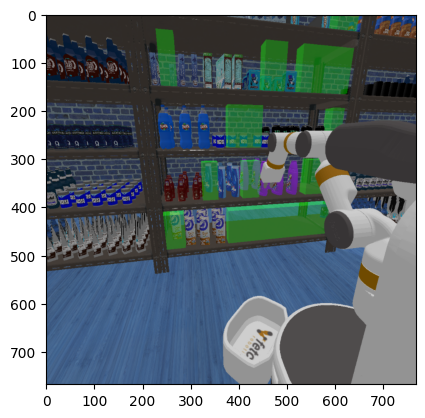

In [11]:
plt.imshow(obs['left_base_camera_link']['image'])


##### item_bboxes = env.unwrapped._get_product_bboxes(1)
board_bbox = env.unwrapped._get_shelf_bbox()
# item_bboxes

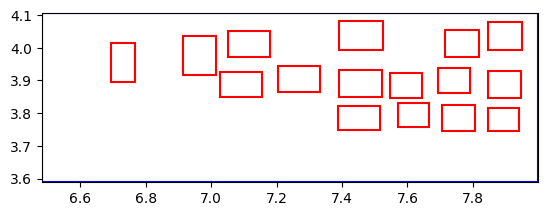

In [149]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
# bboxes = [[0, 0, 2, 1], [3, 1, 5, 4]]  # [[x_min, y_min, x_max, y_max], ...]
fig, ax = plt.subplots()
ax.set_aspect("equal")

for xmin, ymin, xmax, ymax in [board_bbox]:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="blue", linewidth=1.5)
    ax.add_patch(rect)
    
for xmin, ymin, xmax, ymax in item_bboxes:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="red", linewidth=1.5)
    ax.add_patch(rect)
all_bboxes = [board_bbox] + item_bboxes

# Optional: include all boxes in view
if all_bboxes:
    xs = [c for b in all_bboxes for c in (b[0], b[2])]
    ys = [c for b in all_bboxes for c in (b[1], b[3])]
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
plt.show()

# Marching Box

In [150]:
def is_in_collision(rect, others, allow_touch: bool = False) -> bool:
    """
    Returns True if `rect` collides with any bbox in `others`, else False.
    allow_touch=True  -> touching edges/corners is NOT collision
    allow_touch=False -> touching counts as collision
    """
    rx1, ry1, rx2, ry2 = rect
    if not (rx2 > rx1 and ry2 > ry1):
        raise ValueError("Invalid rect")
    for ox1, oy1, ox2, oy2 in others:
        if not (ox2 > ox1 and oy2 > oy1):
            continue  # skip invalid boxes in others
        if allow_touch:
            hit = (rx1 < ox2) and (rx2 > ox1) and (ry1 < oy2) and (ry2 > oy1)
        else:
            hit = (rx1 <= ox2) and (rx2 >= ox1) and (ry1 <= oy2) and (ry2 >= oy1)
        if hit:
            return True
    return False
    
def is_rect_inside(inner, outer, allow_touch: bool = False) -> bool:
    """
    Returns True if `inner` is inside `outer`.
    allow_touch=True  -> edges may coincide (inside-or-on-boundary)
    allow_touch=False -> strict inside (no touching boundary)
    """
    ix1, iy1, ix2, iy2 = inner
    ox1, oy1, ox2, oy2 = outer
    if not (ix2 > ix1 and iy2 > iy1 and ox2 > ox1 and oy2 > oy1):
        raise ValueError("Invalid rectangle coordinates")
    if allow_touch:
        return (ox1 <= ix1) and (oy1 <= iy1) and (ix2 <= ox2) and (iy2 <= oy2)
    else:
        return (ox1 < ix1) and (oy1 < iy1) and (ix2 < ox2) and (iy2 < oy2)

In [151]:
def move_rect(rect, marching_direction, step):
    return np.array(rect) + np.concatenate([marching_direction, marching_direction]) * step

def merge_bboxes(a_bbox, b_bbox):
    # print("WTF", a_bbox, b_bbox)
    return np.array([
        min(a_bbox[0], b_bbox[0]),
        min(a_bbox[1], b_bbox[1]),
        max(a_bbox[2], b_bbox[2]),
        max(a_bbox[3], b_bbox[3])
    ])

def find_free_spaces(start_rect, rect_world, shelf_rect, marching_direction=[1, 0], step=0.02):
    free_spaces = []
    if not is_rect_inside(start_rect, shelf_rect):
        print("Start rectangle is not inside the shelf!")
        return None
    current_rect = np.array(start_rect).copy()
    free_region = current_rect.copy()
    rect_growing = False
    while True:
        # print(current_rect, free_region, rect_growing)
        if not is_rect_inside(current_rect, shelf_rect):
            if rect_growing:
                free_spaces.append(free_region)
            break
        if is_in_collision(current_rect, rect_world):
            if rect_growing:
                free_spaces.append(free_region)
                rect_growing = False
        else:
            if rect_growing:
                free_region = merge_bboxes(free_region, current_rect)
            else:
                rect_growing = True
                free_region = current_rect.copy()
                
        current_rect = move_rect(current_rect, marching_direction, step)
    return free_spaces

In [152]:
def get_start_point_and_direction(dir_to_shelf, shelf_bbox, size_h=0.1, size_w=0.1, eps=1e-3):
    shelf_corners = [
        [shelf_bbox[0] + eps + size_w / 2, shelf_bbox[1] + eps + size_h / 2], # bottom left
        [shelf_bbox[0] + eps + size_w / 2, shelf_bbox[3] - eps - size_h / 2], # top left
        [shelf_bbox[2] - eps - size_w / 2, shelf_bbox[3] - eps - size_h / 2], # top right
        [shelf_bbox[2] - eps - size_w / 2, shelf_bbox[1] + eps + size_h / 2] # bottom right
    ]
    if np.abs(np.dot(dir_to_shelf, [1, 0, 0]) - 1) < 1e-2:
        bbox_center = shelf_corners[1] # top left
        direction = [0, -1]
    if np.abs(np.dot(dir_to_shelf, [0, 1, 0]) - 1) < 1e-2:
        bbox_center = shelf_corners[0] # bottom left
        direction = [1, 0]
    if np.abs(np.dot(dir_to_shelf, [-1, 0, 0]) - 1) < 1e-2:
        bbox_center = shelf_corners[3] # bottom right
        direction = [0, 1]
    if np.abs(np.dot(dir_to_shelf, [0, -1, 0]) - 1) < 1e-2:
        bbox_center = shelf_corners[2] # top right
        direction = [-1, 0]
    start_bbox = [bbox_center[0] - size_w / 2, bbox_center[1] - size_h / 2,
                 bbox_center[0] + size_w / 2, bbox_center[1] + size_h / 2]

    
    
    return start_bbox, direction
        

In [153]:
env.unwrapped.directions_to_shelf[0]

array([-0.00159265, -0.9999988 ,  0.        ], dtype=float32)

In [154]:
board_bbox

[6.481499771118164, 3.588600393676758, 7.998499771118164, 4.105800393676758]

In [155]:
shift = 0.02
board_bbox_eroded = [board_bbox[0] +shift, board_bbox[1] + shift, 
                      board_bbox[2] -shift, board_bbox[3] - shift]
start_bbox, direction = get_start_point_and_direction([1, 0, 0], board_bbox_eroded)
start_bbox, direction

([6.502499771118164, 3.9848003936767586, 6.602499771118164, 4.084800393676758],
 [0, -1])

In [156]:
free_spaces = find_free_spaces(start_bbox, item_bboxes, board_bbox_eroded, marching_direction=direction)

In [157]:
free_spaces

[array([6.50249977, 3.62480039, 6.60249977, 4.08480039])]

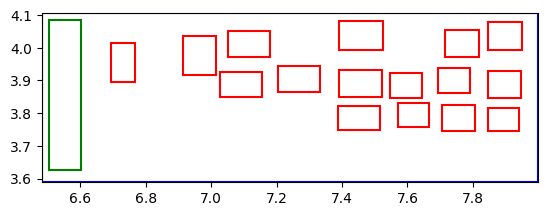

In [158]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
# bboxes = [[0, 0, 2, 1], [3, 1, 5, 4]]  # [[x_min, y_min, x_max, y_max], ...]
fig, ax = plt.subplots()
ax.set_aspect("equal")

for xmin, ymin, xmax, ymax in [board_bbox]:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="blue", linewidth=1.5)
    ax.add_patch(rect)
    
for xmin, ymin, xmax, ymax in item_bboxes:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="red", linewidth=1.5)
    ax.add_patch(rect)

for xmin, ymin, xmax, ymax in free_spaces:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="green", linewidth=1.5)
    ax.add_patch(rect)

all_bboxes = [board_bbox] + item_bboxes + free_spaces

# Optional: include all boxes in view
if all_bboxes:
    xs = [c for b in all_bboxes for c in (b[0], b[2])]
    ys = [c for b in all_bboxes for c in (b[1], b[3])]
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
plt.show()

# Occup map

In [104]:
import numpy as np
from typing import List, Tuple

BBox = Tuple[float, float, float, float]  # (x_min, y_min, x_max, y_max)

def build_occupancy_map(
    shelf_bbox: BBox,
    item_bboxes: List[BBox],
    resolution: float = 0.01,
) -> Tuple[np.ndarray, Tuple[float, float, float], Tuple[float, float]]:
    """
    Build occupancy map for one shelf.

    Args:
        shelf_bbox: (sx1, sy1, sx2, sy2) in world coords.
        item_bboxes: list of (x1, y1, x2, y2) in same coords.
        resolution: cell size in world units (e.g. meters/cell).

    Returns:
        occ: np.ndarray[H, W], uint8
             0 = free, 1 = occupied
        grid_meta: (x0, y0, resolution), where (x0,y0)=shelf min corner.
        map_size_world: (shelf_width, shelf_height)
    """
    sx1, sy1, sx2, sy2 = shelf_bbox
    if not (sx2 > sx1 and sy2 > sy1):
        raise ValueError("Invalid shelf bbox")
    if resolution <= 0:
        raise ValueError("resolution must be > 0")

    shelf_w = sx2 - sx1
    shelf_h = sy2 - sy1

    # Grid size (cover full shelf)
    W = int(np.ceil(shelf_w / resolution))
    H = int(np.ceil(shelf_h / resolution))

    occ = np.zeros((H, W), dtype=np.uint8)

    def world_to_grid_floor(x: float, y: float) -> Tuple[int, int]:
        gx = int(np.floor((x - sx1) / resolution))
        gy = int(np.floor((y - sy1) / resolution))
        return gx, gy

    def world_to_grid_ceil(x: float, y: float) -> Tuple[int, int]:
        gx = int(np.ceil((x - sx1) / resolution))
        gy = int(np.ceil((y - sy1) / resolution))
        return gx, gy

    for (x1, y1, x2, y2) in item_bboxes:
        # Ignore invalid boxes
        if not (x2 > x1 and y2 > y1):
            continue

        # Clip item to shelf (only overlap part matters)
        ix1 = max(x1, sx1)
        iy1 = max(y1, sy1)
        ix2 = min(x2, sx2)
        iy2 = min(y2, sy2)

        if not (ix2 > ix1 and iy2 > iy1):
            continue

        # Conservative rasterization:
        # floor for start, ceil for end -> mark any touched cell occupied
        gx1, gy1 = world_to_grid_floor(ix1, iy1)
        gx2, gy2 = world_to_grid_ceil(ix2, iy2)

        # Clamp to array bounds
        gx1 = max(0, min(W, gx1))
        gy1 = max(0, min(H, gy1))
        gx2 = max(0, min(W, gx2))
        gy2 = max(0, min(H, gy2))

        if gx2 > gx1 and gy2 > gy1:
            occ[gy1:gy2, gx1:gx2] = 1

    return occ, (sx1, sy1, resolution), (shelf_w, shelf_h)

In [105]:
occ, (sx1, sy1, resolution), _ = build_occupancy_map(board_bbox, item_bboxes) 

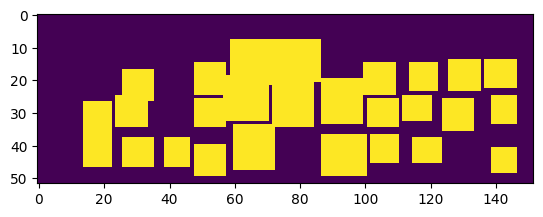

In [106]:
plt.imshow(occ)

In [107]:
np.unique(occ)

array([0, 1], dtype=uint8)

In [108]:
import cv2
def erode_occupancy_map(
    occ: np.ndarray,
    rect_size: Tuple[int, int],  # (width_cells, height_cells)
) -> np.ndarray:
    """
    Erode occupancy map with rectangular kernel using OpenCV.
    Input convention:
      - occ: 2D array, 0=free, 1=occupied
    Output:
      - eroded_occ: same convention (0=free, 1=occupied)
    Notes:
      - To find where a rectangle can fit, it's usually better to erode the FREE mask.
        This function keeps your occupancy convention and does:
          free = (occ == 0)
          free_eroded = erode(free, kernel)
          eroded_occ = 1 - free_eroded
    """
    if occ.ndim != 2:
        raise ValueError("occ must be a 2D array")
    kw, kh = rect_size
    if kw <= 0 or kh <= 0:
        raise ValueError("rect_size must be positive")
    # Convert to uint8 binary free-mask: 255=free, 0=occupied
    free_u8 = (occ == 0).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kw, kh))
    free_eroded = cv2.erode(free_u8, kernel, iterations=1)
    # Back to occupancy convention: 1=occupied, 0=free
    eroded_occ = (free_eroded == 0).astype(np.uint8)
    return eroded_occ


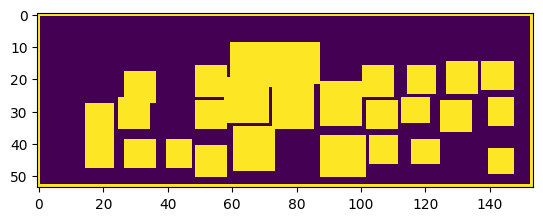

In [109]:
occ_padded = np.ones((occ.shape[0] + 2, occ.shape[1] + 2))
occ_padded[1:-1, 1:-1] = occ
plt.imshow(occ_padded)

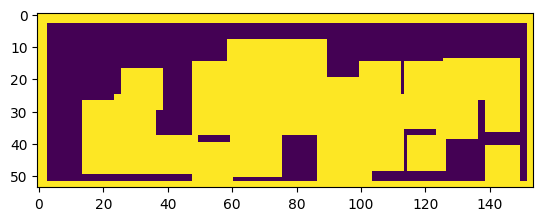

In [110]:
occ_padded_eroded = erode_occupancy_map(occ_padded, (4, 4))
plt.imshow(occ_padded_eroded)

(<matplotlib.image.AxesImage at 0x7f4db66aa500>, array([0, 1], dtype=uint8))

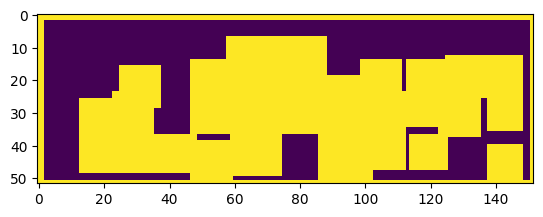

In [111]:
occ_eroded = occ_padded_eroded[1:-1, 1:-1]
plt.imshow(occ_eroded), np.unique(occ_eroded)

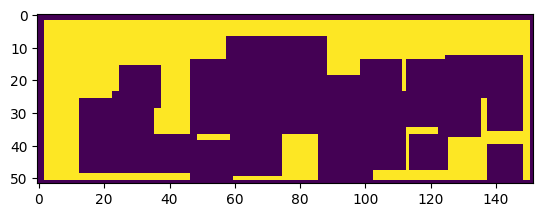

In [137]:
free_map = 1 - occ_eroded
plt.imshow(free_map)

In [138]:
def largest_rectangle_in_binary_matrix(mask: np.ndarray, target_value: int = 1) -> Tuple[int, int, int, int, int]:
    """
    Find the largest axis-aligned rectangle consisting only of target_value.
    Args:
        mask: 2D array-like (binary/int/bool).
        target_value: value treated as "fillable" (default=1).
    Returns:
        (x_min, y_min, x_max, y_max, area)
        where x_max/y_max are exclusive bounds.
        If none found -> (0, 0, 0, 0, 0)
    """
    if mask.ndim != 2:
        raise ValueError("mask must be 2D")
    # Normalize to 0/1 where 1 means usable cell
    m = (mask == target_value).astype(np.uint8)
    H, W = m.shape
    heights = np.zeros(W, dtype=np.int32)
    best_area = 0
    best = (0, 0, 0, 0)  # x1, y1, x2, y2
    for y in range(H):
        # Build histogram of consecutive 1s ending at row y
        heights = np.where(m[y] == 1, heights + 1, 0)
        # Largest rectangle in histogram (monotonic stack of (start_idx, height))
        stack = []
        for i in range(W + 1):
            cur_h = heights[i] if i < W else 0  # sentinel
            start = i
            while stack and stack[-1][1] > cur_h:
                idx, h = stack.pop()
                area = h * (i - idx)
                if area > best_area:
                    best_area = area
                    x1 = idx
                    x2 = i
                    y2 = y + 1
                    y1 = y2 - h
                    best = (x1, y1, x2, y2)
                start = idx
            if not stack or stack[-1][1] < cur_h:
                stack.append((start, cur_h))
    x1, y1, x2, y2 = best
    return x1, y1, x2, y2, best_area

In [139]:
min_size = (0.1 / resolution, 0.1 / resolution)
min_size

(10.0, 10.0)

(2, 2, 151, 7, 745)
149 5
(2, 7, 13, 51, 484)
11 44
WTF! (2, 7, 13, 51)
(89, 7, 151, 13, 372)
62 6
(13, 7, 58, 14, 315)
45 7
(38, 14, 47, 37, 207)
9 23
(126, 38, 138, 51, 156)
12 13
WTF! (126, 38, 138, 51)
(75, 37, 86, 51, 154)
11 14
WTF! (75, 37, 86, 51)
(13, 14, 25, 24, 120)
12 10
(149, 13, 151, 51, 76)
2 38


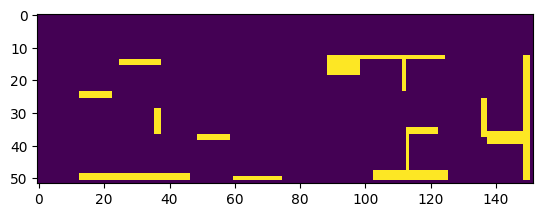

In [140]:
free_areas = []
while True:
    res = largest_rectangle_in_binary_matrix(free_map)
    print(res)
    free_area = res[:-1]
    area = res[-1]
    print(free_area[2] - free_area[0], free_area[3] - free_area[1])
    if area < min_size[0] * min_size[1]:
        break
    if free_area[2] - free_area[0] > min_size[0] and free_area[3] - free_area[1] > min_size[1]:
        print("WTF!", free_area)
    free_areas.append(free_area)
    free_map[free_area[1]:free_area[3], free_area[0]:free_area[2]] = 0
    plt.imshow(free_map)

In [141]:
free_areas

[(2, 2, 151, 7),
 (2, 7, 13, 51),
 (89, 7, 151, 13),
 (13, 7, 58, 14),
 (38, 14, 47, 37),
 (126, 38, 138, 51),
 (75, 37, 86, 51),
 (13, 14, 25, 24)]

In [142]:
def point_idx_to_xy(point, start_point, descr=0.01):
    return np.array(point) * descr + start_point
def rect_idxs_to_xy(rects, start_point, descr=0.01):
    res = []
    for rect in rects:
        xy_min = point_idx_to_xy(rect[:2], start_point=start_point, descr=descr)
        xy_max = point_idx_to_xy(rect[2:], start_point=start_point, descr=descr)
        res.append([xy_min[0], xy_min[1], xy_max[0], xy_max[1]])
    return np.array(res)

In [143]:
free_rects = rect_idxs_to_xy(free_areas, [sx1, sy1])

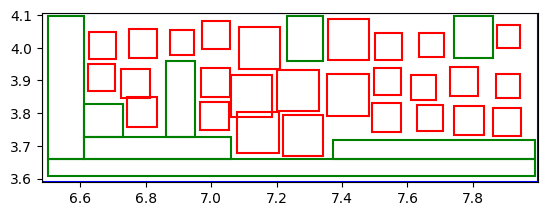

In [144]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
# bboxes = [[0, 0, 2, 1], [3, 1, 5, 4]]  # [[x_min, y_min, x_max, y_max], ...]
fig, ax = plt.subplots()
ax.set_aspect("equal")

for xmin, ymin, xmax, ymax in [board_bbox]:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="blue", linewidth=1.5)
    ax.add_patch(rect)
    
for xmin, ymin, xmax, ymax in item_bboxes:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="red", linewidth=1.5)
    ax.add_patch(rect)

for xmin, ymin, xmax, ymax in free_rects:
    w, h = xmax - xmin, ymax - ymin
    rect = Rectangle((xmin, ymin), w, h, fill=False, edgecolor="green", linewidth=1.5)
    ax.add_patch(rect)

all_bboxes = [board_bbox] + item_bboxes

# Optional: include all boxes in view
if all_bboxes:
    xs = [c for b in all_bboxes for c in (b[0], b[2])]
    ys = [c for b in all_bboxes for c in (b[1], b[3])]
    ax.set_xlim(min(xs), max(xs))
    ax.set_ylim(min(ys), max(ys))
plt.show()

# Result

In [1]:
import sapien
import sys
import json
import gymnasium as gym
import torch
from tqdm import tqdm
import argparse
import os
from pathlib import Path
import time 
import hydra
import matplotlib.pyplot as plt
import cv2
import os
os.chdir('..')

import mani_skill.envs
from mani_skill.utils.wrappers import RecordEpisode
from mani_skill.utils.structs.pose import Pose

import sys 
sys.path.append('..')
from dsynth.envs import *
from dsynth.robots import *
from dsynth.auxiliary.empty_space_detection import detect_free_spaces
from dsynth.annotate_obs import prepare_observations, extract_reachable_products

/data/home/soshin/envs/dsynth/lib/python3.10/site-packages/sapien/__init__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/data/home/soshin/envs/dsynth/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
env = gym.make('PickToBasketContEnv', 
                   robot_uids='ds_fetch_basket', 
                   config_dir_path = '/data/home/soshin/repo/darkstore-synthesizer/generated_envs/cluttered',
                   num_envs=1, 
                   viewer_camera_configs={'shader_pack': 'default'}, 
                    human_render_camera_configs={'shader_pack': 'default'},
                    sensor_configs={'shader_pack': 'default'},
                   render_mode="rgb_array",
                #    render_mode="rgb_array", 
                   control_mode='pd_ee_delta_pose',
                   enable_shadow=True,
                   sim_config={'spacing': 20},
                   obs_mode='rgb+segmentation',
                   sim_backend='auto',
                   parallel_in_single_scene = False,
                   )

/data/home/soshin/envs/dsynth/lib/python3.10/site-packages/torch/random.py:187: UserWarning: CUDA reports that you have 2 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you are only making use of a few CUDA devices, set the environment variable CUDA_VISIBLE_DEVICES or the 'devices' keyword argument of fork_rng with the set of devices you are actually using. For example, if you are using CPU only, set device.upper()_VISIBLE_DEVICES= or devices=[]; if you are using device 0 only, set CUDA_VISIBLE_DEVICES=0 or devices=[0].  To initialize all devices and suppress this warning, set the 'devices' keyword argument to `range(torch.cuda.device_count())`.
  warnings.warn(message)
/data/home/soshin/repo/darkstore-synthesizer/dsynth/envs/darkstore_cont_base.py:193: UserWarning: Creating a tensor from a list of nump

built
Total 115 products in 1 scene(s)


In [3]:
_ = env.unwrapped.reset(420, options={'reconfigure': True})

built
Total 115 products in 1 scene(s)


In [4]:
obs = prepare_observations(env)

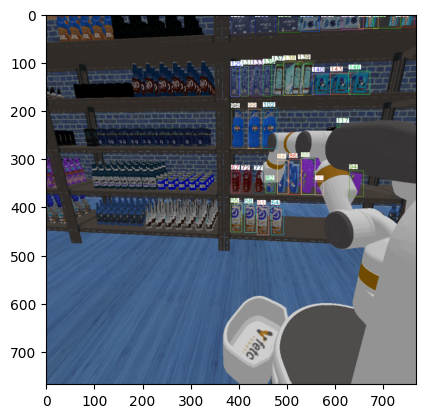

In [5]:
plt.imshow(obs['left_base_camera_link']['annotated_image'])

In [6]:
obs['scene_description']

{'robot': {'base_position': [2.802, 6.349, 0.0],
  'ee_position': [1.967, 6.096, 0.771],
  'joints': [{'name': 'torso_lift_joint', 'qpos': 0.0, 'limits': [0.0, 0.386]},
   {'name': 'head_pan_joint', 'qpos': 0.0, 'limits': [-1.57, 1.57]},
   {'name': 'shoulder_pan_joint', 'qpos': 0.0, 'limits': [-1.606, 1.606]},
   {'name': 'head_tilt_joint', 'qpos': 0.0, 'limits': [-0.76, 1.45]},
   {'name': 'shoulder_lift_joint', 'qpos': -0.785, 'limits': [-1.221, 1.518]},
   {'name': 'upperarm_roll_joint', 'qpos': 0.0, 'limits': [-3.141, 3.141]},
   {'name': 'elbow_flex_joint', 'qpos': 0.785, 'limits': [-2.251, 2.251]},
   {'name': 'forearm_roll_joint', 'qpos': 0.0, 'limits': [-3.141, 3.141]},
   {'name': 'wrist_flex_joint', 'qpos': 1.047, 'limits': [-2.16, 2.16]},
   {'name': 'wrist_roll_joint', 'qpos': 0.0, 'limits': [-3.141, 3.141]},
   {'name': 'r_gripper_finger_joint', 'qpos': 0.015, 'limits': [0.0, 0.05]},
   {'name': 'l_gripper_finger_joint', 'qpos': 0.015, 'limits': [0.0, 0.05]}]},
 'shelf': 

In [7]:
obs_free = detect_free_spaces(env)

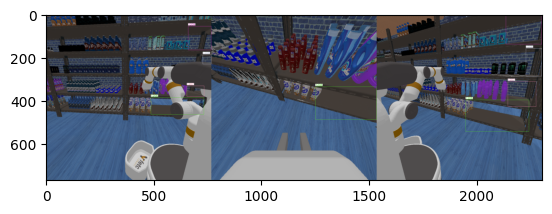

In [8]:
plt.imshow(obs_free['combined']['annotated_image'])

In [9]:
cv2.imwrite('output_image.jpg', obs_free['combined']['annotated_image'])

True

In [10]:
obs_free['spaces_description']

[{'free_space': 1206, 'num_board': 0},
 {'free_space': 1207, 'num_board': 1},
 {'free_space': 1208, 'num_board': 2},
 {'free_space': 1209, 'num_board': 3},
 {'free_space': 1210, 'num_board': 4}]